In [56]:
import os
import zipfile

zip_filename = 'plantvillage.zip'
target_dir = './tomato_dataset'

# will Download only if zip doesn't exist
if not os.path.exists(zip_filename):
    print("Downloading dataset...")
    !kaggle datasets download -d mohitsingh1804/plantvillage
    print("Download complete!")
else:
    print(f"'{zip_filename}' exists)

#Extract  only if it hasn't been extracted 
if not os.path.exists(target_dir):
    print("Extracting dataset...")
    os.makedirs(target_dir, exist_ok=True)
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(target_dir)
    print("Extracted")
else:
    print("already extracted")

'plantvillage.zip' already exists. Skipping download.
already extracted


In [57]:
import torch
import torch.nn as nn

import torchvision
from torchvision.datasets import ImageFolder
import torchvision.transforms.v2 as T
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [58]:
dataset_path = "./tomato_dataset/PlantVillage"

train_dir = f"./tomato_dataset/PlantVillage/train"

val_dir = f"./tomato_dataset/PlantVillage/val"

In [59]:
temp_transform = transforms.ToTensor()

train_dataset = datasets.ImageFolder(

    train_dir,

    transform=temp_transform

)

loader = DataLoader(train_dataset, batch_size=64, shuffle=False)

mean = 0.

std = 0.

total_images = 0

for images, _ in loader:

    batch_size = images.size(0)

    images = images.view(batch_size, images.size(1), -1)

    mean += images.mean(2).sum(0)

    std += images.std(2).sum(0)

    total_images += batch_size

mean /= total_images

std /= total_images

print("Mean:", mean)

print("Std:", std)

Mean: tensor([0.4496, 0.4651, 0.4003])
Std: tensor([0.1656, 0.1448, 0.1831])


In [60]:
transform = T.Compose([  
    T.Resize((64,64)), 
    T.ToImage(),       
    T.ToDtype(torch.float32, scale=True), 
    T.Normalize(mean.tolist(), std.tolist())
    
])


In [61]:
train_data = ImageFolder(
    root="./tomato_dataset/PlantVillage/train", 
    transform=transform
)

val_data = ImageFolder(
    root="./tomato_dataset/PlantVillage/val", 
    transform=transform
)



In [81]:
train_loader = DataLoader(
    train_data, 
    batch_size=64, 
    shuffle=True ,
    num_workers=4,
)

val_loader = DataLoader(
    val_data,
    batch_size=64,
    shuffle=False ,
    num_workers=4,
)


In [82]:
images, labels = next(iter(train_loader))

print(images.shape)
print(images.dtype)
print(labels.shape)
print(images.min(), images.max())

torch.Size([64, 3, 64, 64])
torch.float32
torch.Size([64])
tensor(-3.1042) tensor(3.3697)


In [83]:
conv1 = nn.Conv2d(
    in_channels=3,
    out_channels=32,
    kernel_size=3,
    stride=1,
    padding=1
)

out = conv1(images)

print(out.shape)

torch.Size([64, 32, 64, 64])


In [84]:
relu = nn.ReLU()

out = relu(out)

print(out.shape)

torch.Size([64, 32, 64, 64])


In [85]:
pool = nn.MaxPool2d(
    kernel_size=2,
    stride=2
)

out = pool(out)

print(out.shape)

torch.Size([64, 32, 32, 32])


In [86]:
print(conv1.weight.shape)
print(conv1.bias.shape)

torch.Size([32, 3, 3, 3])
torch.Size([32])


In [87]:
sum(p.numel() for p in conv1.parameters())

896

In [88]:
image = images[:1]
feature_maps = conv1(image)
print(feature_maps.shape)



torch.Size([1, 32, 64, 64])


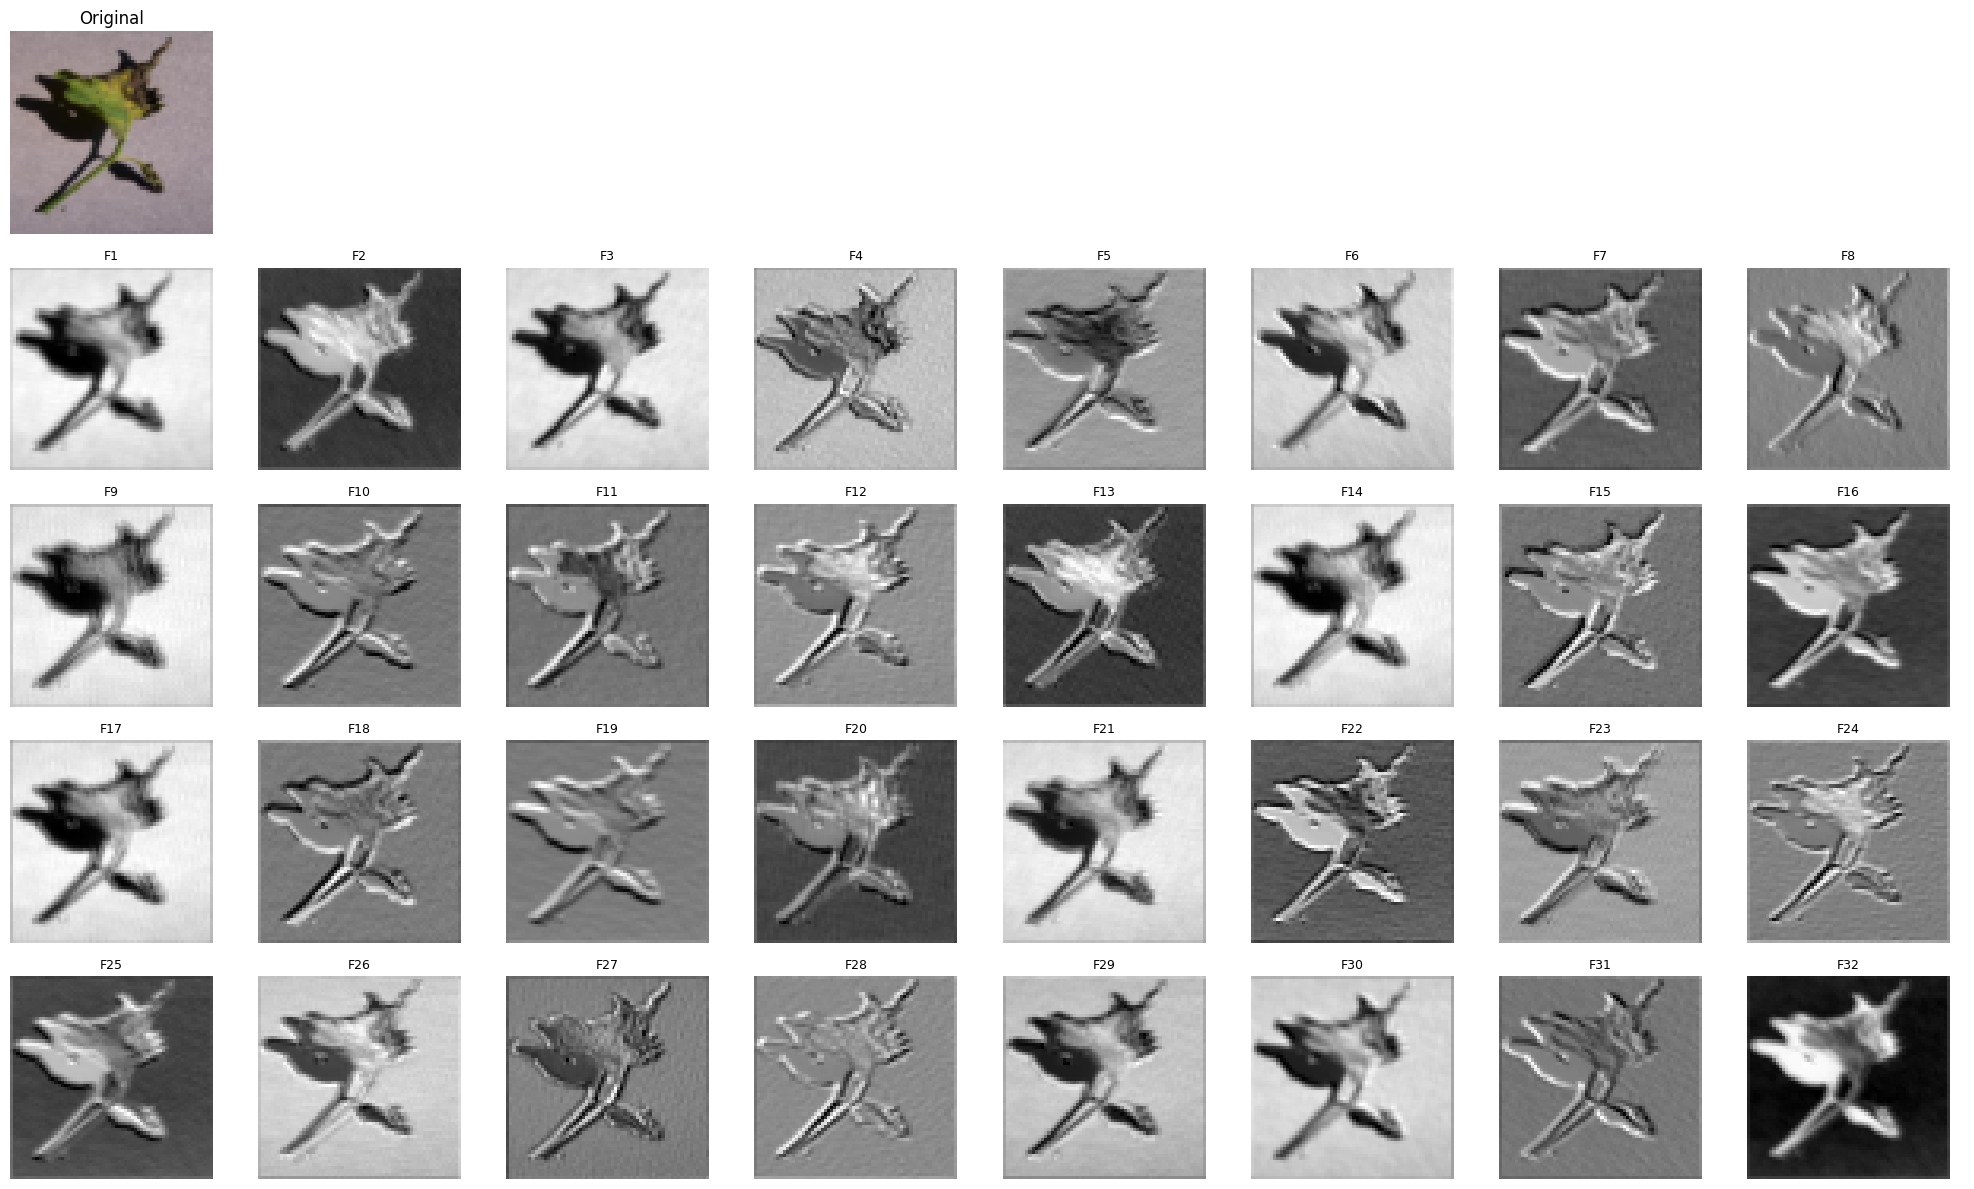

In [89]:
import matplotlib.pyplot as plt

image = images[:1]
feature_maps = conv1(image)

fig, axes = plt.subplots(5, 8, figsize=(20, 12))

# Original image
img = images[0].permute(1, 2, 0).cpu()

# Undo normalization
img = img * std + mean
img = img.clamp(0, 1)

axes[0, 0].imshow(img)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

# Hide remaining empty cells in first row
for j in range(1, 8):
    axes[0, j].axis("off")

# Plot all 32 feature maps
for i in range(32):
    row = (i // 8) + 1
    col = i % 8

    axes[row, col].imshow(
        feature_maps[0, i].detach().cpu(),
        cmap="gray"
    )
    axes[row, col].set_title(f"F{i+1}", fontsize=9)
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [90]:
weights = conv1.weight.detach().cpu()

print(weights.shape)
# (32, 3, 3, 3)

torch.Size([32, 3, 3, 3])


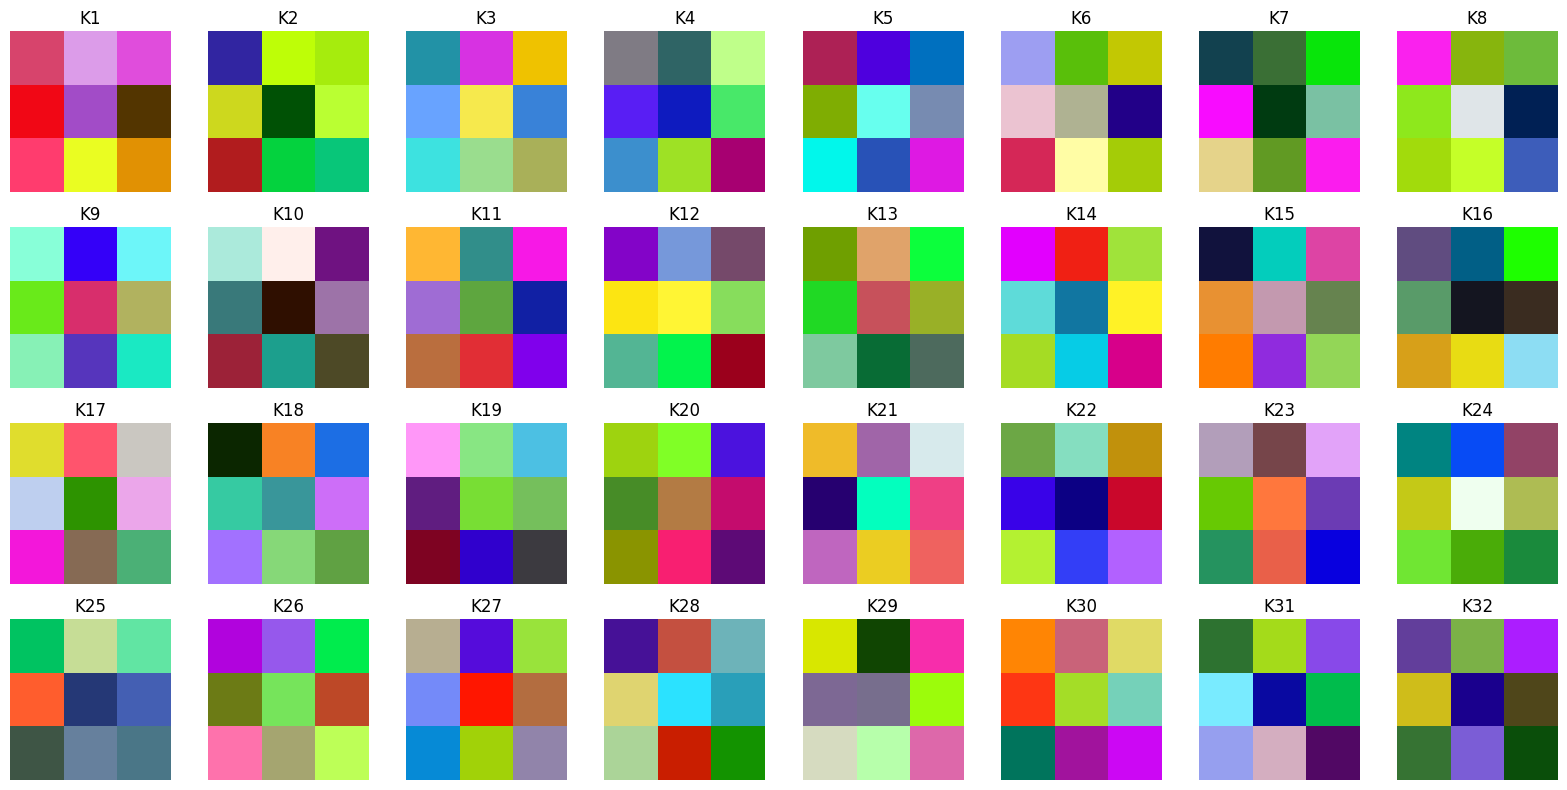

In [91]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 8, figsize=(16, 8))

for i, ax in enumerate(axes.flat):
    kernel = weights[i]

    # Normalize each kernel for visualization
    kernel = kernel.permute(1, 2, 0)
    kernel = (kernel - kernel.min()) / (kernel.max() - kernel.min())

    ax.imshow(kernel)
    ax.set_title(f"K{i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [92]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
num_classes = len(train_dataset.classes)

In [93]:
from functools import partial
import torch.nn as nn

DefaultConv2d = partial(
    nn.Conv2d,
    kernel_size=3,
    padding="same"
)

model = nn.Sequential(

    nn.Conv2d(3, 64, kernel_size=7, padding="same"),

    nn.BatchNorm2d(64),

    nn.LeakyReLU(negative_slope=0.01),

    nn.MaxPool2d(2),

    DefaultConv2d(64, 128),

    nn.BatchNorm2d(128),

    nn.LeakyReLU(0.01),

    DefaultConv2d(128, 128),

    nn.BatchNorm2d(128),

    nn.LeakyReLU(0.01),

    nn.MaxPool2d(2),

    DefaultConv2d(128, 256),

    nn.BatchNorm2d(256),

    nn.LeakyReLU(0.01),

    DefaultConv2d(256, 256),

    nn.BatchNorm2d(256),

    nn.LeakyReLU(0.01),

    nn.MaxPool2d(2),

    nn.Flatten(),

    nn.Linear(256 * 8 * 8, 128),

    nn.LeakyReLU(0.01),

    nn.Dropout(0.2),

    nn.Linear(128, 64),

    nn.LeakyReLU(0.01),

    nn.Dropout(0.3),

    nn.Linear(64, num_classes)

).to(device)


def kaiming_init(module):
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(
            module.weight,
            mode="fan_in",
            nonlinearity="leaky_relu"
        )

        if module.bias is not None:
            nn.init.zeros_(module.bias)

model.apply(kaiming_init)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), padding=same)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.01)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): LeakyReLU(negative_slope=0.01)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (9): LeakyReLU(negative_slope=0.01)
  (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (11): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (13): LeakyReLU(negati

In [94]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [95]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(total_params)
print(trainable_params)

3224010
3224010


In [96]:
print(model)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), padding=same)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.01)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): LeakyReLU(negative_slope=0.01)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (9): LeakyReLU(negative_slope=0.01)
  (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (11): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (13): LeakyReLU(negati

In [97]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print(images.shape)
print(outputs.shape)

torch.Size([64, 3, 64, 64])
torch.Size([64, 10])


In [100]:
num_epochs = 20
import time
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    start = time.time()

    
    # Training
    
    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

       
        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, dim=1)

        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = train_correct / train_total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)


    # Validation
    
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, dim=1)

            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
        f"Epoch time: {time.time() - start:.2f} seconds"
    )

Epoch [1/20] Train Loss: 1.6701 | Train Acc: 0.5203 | Val Loss: 1.1043 | Val Acc: 0.6387Epoch time: 76.31 seconds
Epoch [2/20] Train Loss: 0.9094 | Train Acc: 0.7057 | Val Loss: 0.6761 | Val Acc: 0.7838Epoch time: 76.83 seconds
Epoch [3/20] Train Loss: 0.7883 | Train Acc: 0.7481 | Val Loss: 0.5896 | Val Acc: 0.8141Epoch time: 76.27 seconds
Epoch [4/20] Train Loss: 0.6211 | Train Acc: 0.8066 | Val Loss: 0.5473 | Val Acc: 0.8422Epoch time: 76.09 seconds
Epoch [5/20] Train Loss: 0.5276 | Train Acc: 0.8330 | Val Loss: 0.3275 | Val Acc: 0.8951Epoch time: 76.64 seconds
Epoch [6/20] Train Loss: 0.5134 | Train Acc: 0.8354 | Val Loss: 0.4668 | Val Acc: 0.8540Epoch time: 76.41 seconds
Epoch [7/20] Train Loss: 0.4371 | Train Acc: 0.8582 | Val Loss: 0.5638 | Val Acc: 0.8169Epoch time: 76.67 seconds
Epoch [8/20] Train Loss: 0.3820 | Train Acc: 0.8778 | Val Loss: 0.3998 | Val Acc: 0.8733Epoch time: 76.40 seconds
Epoch [9/20] Train Loss: 0.3773 | Train Acc: 0.8901 | Val Loss: 0.2452 | Val Acc: 0.9212

FileNotFoundError: [Errno 2] No such file or directory: 'images/confusion_matrix.png'

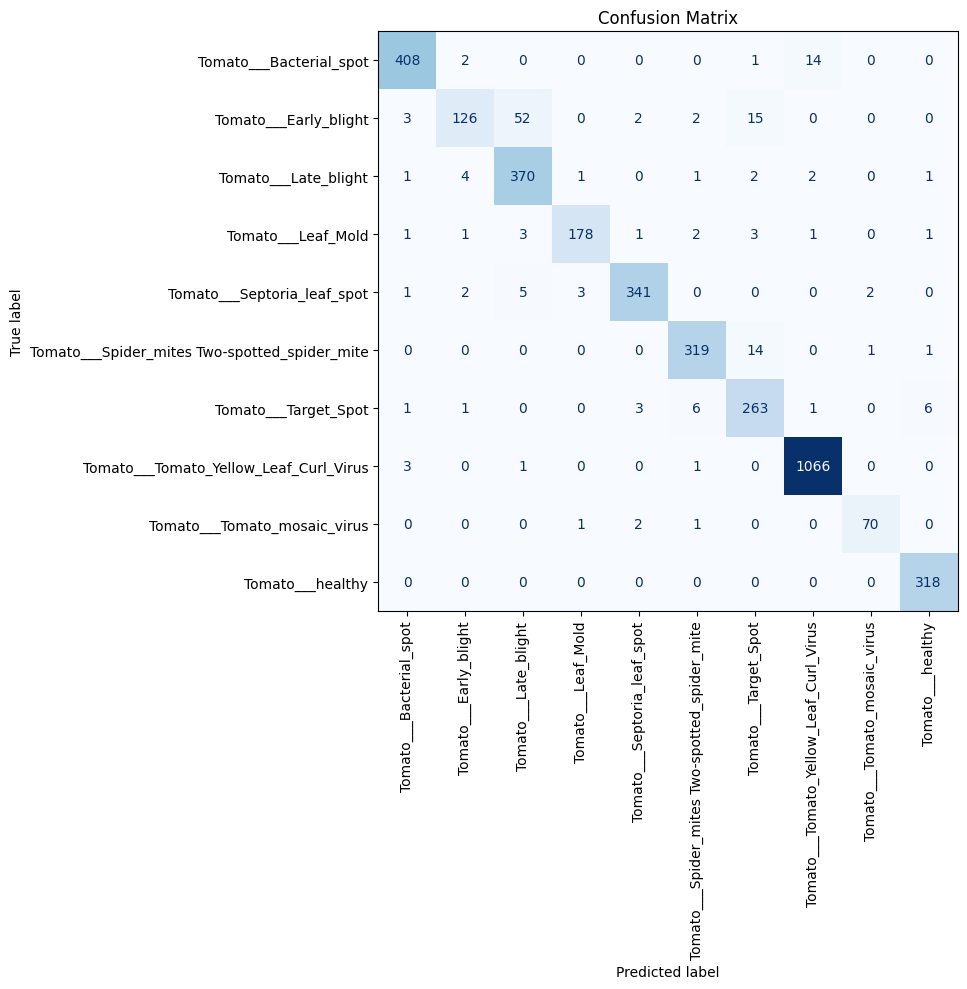

In [104]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Put model in evaluation mode
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d",
    ax=plt.gca(),
    colorbar=False
)

plt.title("Confusion Matrix")
plt.tight_layout()


plt.show()